In [1]:
!nvidia-smi
!nvcc --version
!pip install nvcc4jupyter
%load_ext nvcc4jupyter

Mon Mar 30 09:00:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Configuration File

In [2]:
%%writefile aes.cuh

Writing aes.cuh


AES Logic File

In [3]:
%%writefile aes.cu


Writing aes.cu


Main File

In [4]:
%%writefile main.cu


Writing main.cu


Makefile

In [6]:
%%writefile Makefile

Writing Makefile


In [ ]:
import os

sizes_gb = [1, 2, 4, 8]

for size in sizes_gb:
    file_path = f"/content/test_{size}GB.bin"
    print(f"Creating {size}GB file...")
    
    with open(file_path, "wb") as f:
        for i in range(size):
            # Write 1GB chunk to avoid RAM overload
            f.write(os.urandom(1024 * 1024 * 1024))
            print(f"Written GB {i+1} of {size}")
            
    print(f"Completed: {file_path}\n")

In [ ]:
with open("/content/test_1GB.bin", "rb") as f: # Read in binary mode for .bin files
    print(f.read(10))

b'W\xd1_\x9b~+\xef^?\xc4'


In [7]:
!make

nvcc -O2 -c main.cu
nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
nvcc -O2 -c aes.cu
nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
nvcc -O2 -o main main.o aes.o
nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [12]:
!./main test_8GB.bin

Cifrato con successo. Tempo impiegato: 66369.4 ms


Reading data from: /content/data.csv


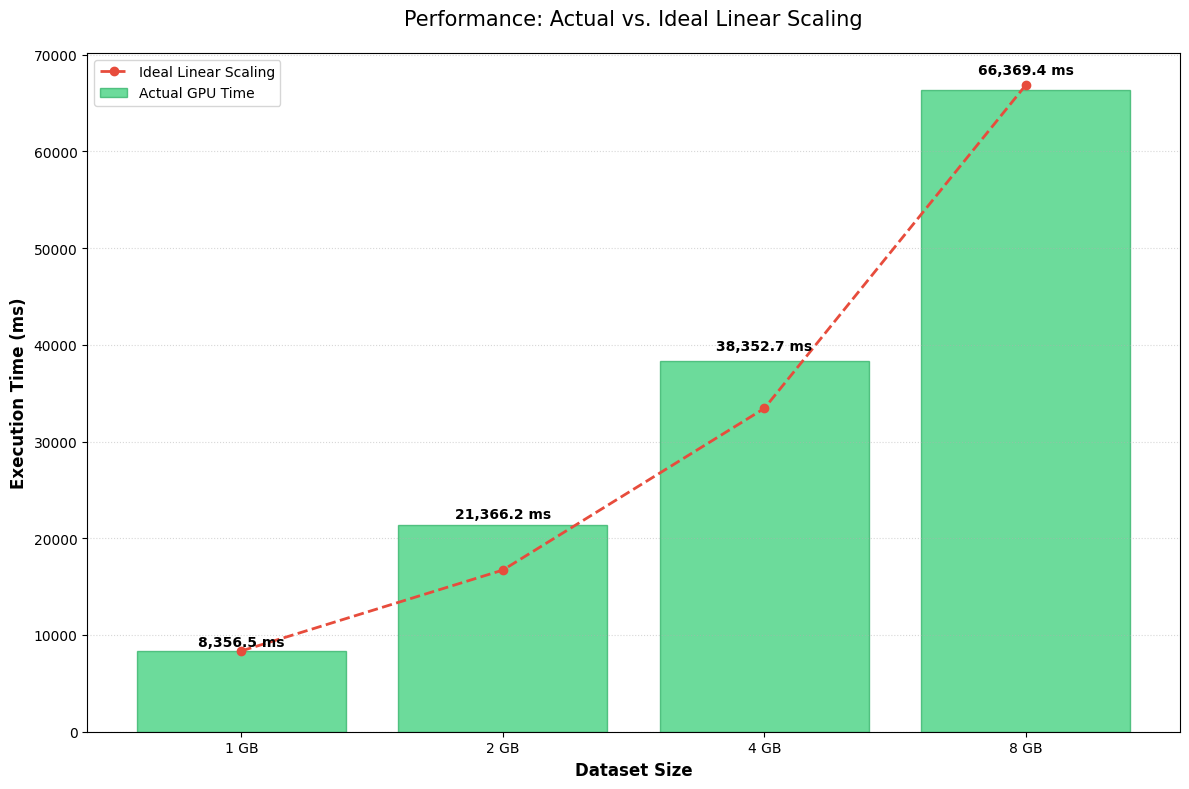

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import re

file_path =  "/content/data.csv"

try:
    data = []
    regex_pattern = r"test_(\d+)GB\.bin,\s*Time:\s*([\d\.]+)\s*ms"
    
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    print(f"Reading data from: {file_path}")

    with open(file_path, 'r') as f:
        for line in f:
            if "GPU Test" in line or "CPU Test" in line:
                match = re.search(regex_pattern, line)
                if match:
                    size_gb = int(match.group(1))
                    execution_time = float(match.group(2))
                    data.append({
                        "Size": size_gb, 
                        "Label": f"{size_gb} GB", 
                        "Time": execution_time
                    })

    if not data:
        raise ValueError("No data found. Check if the file contains 'GPU Test' lines.")

    df = pd.DataFrame(data).sort_values('Size')

    # Calcolo crescita ideale basata sul primo test (1 GB)
    time_1gb = df.iloc[0]['Time']
    df['Ideal_Time'] = df['Size'] * time_1gb

    plt.figure(figsize=(12, 8))
    
    bars = plt.bar(df['Label'], df['Time'], color='#2ecc71', alpha=0.7, 
                   label='Actual GPU Time', edgecolor='#27ae60')

    plt.plot(df['Label'], df['Ideal_Time'], color='#e74c3c', marker='o', 
             linestyle='--', linewidth=2, label='Ideal Linear Scaling')

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + (yval * 0.02), 
                 f'{yval:,.1f} ms', ha='center', va='bottom', 
                 fontsize=10, fontweight='bold')

    plt.xlabel('Dataset Size', fontsize=12, fontweight='bold')
    plt.ylabel('Execution Time (ms)', fontsize=12, fontweight='bold')
    plt.title('Performance: Actual vs. Ideal Linear Scaling', fontsize=15, pad=20)
    plt.legend(loc='upper left')
    plt.grid(axis='y', linestyle=':', alpha=0.5)
    
    plt.tight_layout()
    plt.savefig("performance_plot.png", dpi=300)

except Exception as e:
    print(f"Error: {e}")